# Peak-Shape PCA Analysis of LIBS Spectra

This notebook demonstrates the peak-shape PCA pipeline:
1. Load and standardize a corpus of LIBS spectra
2. Fit peaks across the corpus
3. Compute peak width statistics
4. Extract spectral windows and fit PCA
5. Decompose principal components into physical broadening mechanisms:
   - **Gaussian** (Doppler / instrumental broadening)
   - **Lorentzian** (Stark / natural broadening)
   - **Asymmetric tail** (self-absorption)

In [1]:
%load_ext autoreload
%autoreload 2

import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import voigt_profile as voigt

## 1. Load pre-computed results

Results were computed on `moissanite` using `run_corpus_pca.py` against the
REE LIBS dataset (44 shot-averaged spectra, native 0.0334 nm resolution).

In [2]:
RESULTS_FILE = 'ree_zeroed.pkl'

with open(RESULTS_FILE, 'rb') as f:
    results = pickle.load(f)

stats        = results['width_stats']
components   = results['components']
evr          = results['explained_variance_ratio']
mean_peak    = results['mean_peak']
mean_zeroed  = results['mean_peak_zeroed']
mean_offset  = results['mean_offset']
mean_fit     = results['mean_fit']
scores       = results['scores']
decomps      = results['decompositions']
metadata     = results['peak_metadata']
labels       = results['peak_classifications']
n_comp       = len(evr)
n_window_pts = components.shape[1]
x_norm       = np.linspace(-1, 1, n_window_pts)

print(f"Loaded results from {RESULTS_FILE}")
print(f"  {len(results['csv_files'])} spectra, {scores.shape[0]} peak windows, {n_comp} PCs")

Loaded results from ree_zeroed.pkl
  44 spectra, 24756 peak windows, 5 PCs


## 2. Peak width statistics

Distribution of Voigt FWHM values across 42 fitted spectra (26,831 peaks total).

Min  FWHM: 0.0679 nm
Max  FWHM: 4.1325 nm
Mean FWHM: 0.4561 nm
Median FWHM: 0.3772 nm
Std  FWHM: 0.3117 nm



BIC selects 5 modes:
  mode 1: mean=0.224 nm, std=0.063 nm, weight=41.1%
  mode 2: mean=0.431 nm, std=0.090 nm, weight=30.2%
  mode 3: mean=0.650 nm, std=0.113 nm, weight=19.3%
  mode 4: mean=1.004 nm, std=0.198 nm, weight=7.3%
  mode 5: mean=1.673 nm, std=0.488 nm, weight=2.1%


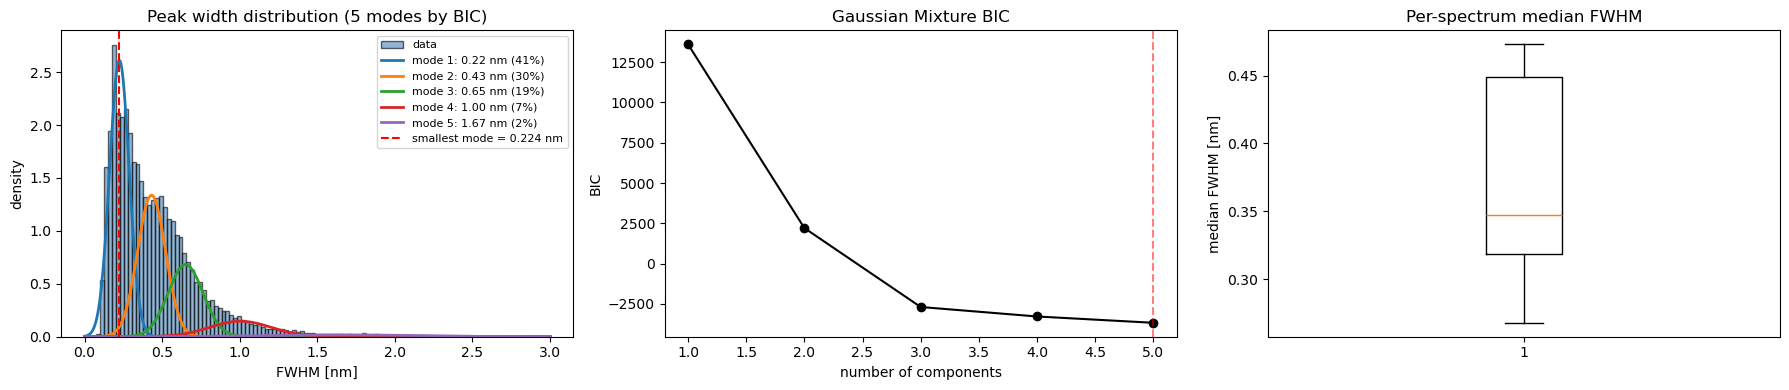

In [3]:
all_widths = np.array(stats['all_widths'])
per_spectrum_median = np.array(stats['per_spectrum_median'])

print(f"Min  FWHM: {stats['min']:.4f} nm")
print(f"Max  FWHM: {stats['max']:.4f} nm")
print(f"Mean FWHM: {stats['mean']:.4f} nm")
print(f"Median FWHM: {stats['median']:.4f} nm")
print(f"Std  FWHM: {stats['std']:.4f} nm")

# --- Fit GMM to detect modes ---
from sklearn.mixture import GaussianMixture

X = all_widths.reshape(-1, 1)
bics = {}
for k in range(1, 6):
    gmm = GaussianMixture(n_components=k, random_state=0, max_iter=200).fit(X)
    bics[k] = gmm.bic(X)
best_k = min(bics, key=bics.get)
best_gmm = GaussianMixture(n_components=best_k, random_state=0, max_iter=200).fit(X)

means = best_gmm.means_.ravel()
stds = np.sqrt(best_gmm.covariances_.ravel())
weights = best_gmm.weights_.ravel()
order = np.argsort(means)
means, stds, weights = means[order], stds[order], weights[order]

print(f"\nBIC selects {best_k} modes:")
for i in range(best_k):
    print(f"  mode {i+1}: mean={means[i]:.3f} nm, std={stds[i]:.3f} nm, weight={weights[i]:.1%}")

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Histogram + GMM overlay
ax = axes[0]
bins = np.linspace(0, min(3.0, stats['max']), 120)
ax.hist(all_widths, bins=bins, density=True, color='steelblue', edgecolor='k', alpha=0.6, label='data')
x_pdf = np.linspace(0, bins[-1], 500)
for i in range(best_k):
    pdf_i = weights[i] * (1 / (stds[i] * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_pdf - means[i]) / stds[i]) ** 2)
    ax.plot(x_pdf, pdf_i, lw=2, label=f'mode {i+1}: {means[i]:.2f} nm ({weights[i]:.0%})')
ax.axvline(means[0], color='r', ls='--', lw=1.5, label=f'smallest mode = {means[0]:.3f} nm')
ax.set_xlabel('FWHM [nm]')
ax.set_ylabel('density')
ax.set_title(f'Peak width distribution ({best_k} modes by BIC)')
ax.legend(fontsize=8)

# BIC curve
ax = axes[1]
ks = sorted(bics.keys())
ax.plot(ks, [bics[k] for k in ks], 'ko-')
ax.axvline(best_k, color='r', ls='--', alpha=0.5)
ax.set_xlabel('number of components')
ax.set_ylabel('BIC')
ax.set_title('Gaussian Mixture BIC')

# Box plot of per-spectrum medians
ax = axes[2]
valid_medians = per_spectrum_median[~np.isnan(per_spectrum_median)]
ax.boxplot(valid_medians, vert=True)
ax.set_ylabel('median FWHM [nm]')
ax.set_title('Per-spectrum median FWHM')

plt.tight_layout()
plt.show()

## 3. PCA on peak-shape windows

25,684 spectral windows (width = 3x median FWHM) were extracted, baseline-subtracted,
normalised to unit height, and resampled to 101 points.

In [4]:
print(f'{scores.shape[0]} peak windows, {n_comp} components')
print(f'Explained variance ratio: {evr}')
print(f'Cumulative: {np.cumsum(evr)}')

24756 peak windows, 5 components
Explained variance ratio: [0.71503381 0.19776073 0.07839791 0.00636093 0.00204745]
Cumulative: [0.71503381 0.91279454 0.99119245 0.99755337 0.99960083]


### 3a. Scree plot

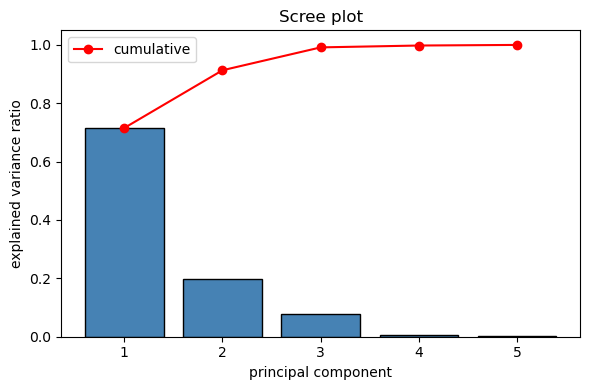

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(1, n_comp + 1), evr, color='steelblue', edgecolor='k')
ax.plot(range(1, n_comp + 1), np.cumsum(evr), 'ro-', label='cumulative')
ax.set_xlabel('principal component')
ax.set_ylabel('explained variance ratio')
ax.set_title('Scree plot')
ax.legend()
plt.tight_layout()
plt.show()

### 3b. Mean peak shape and principal components

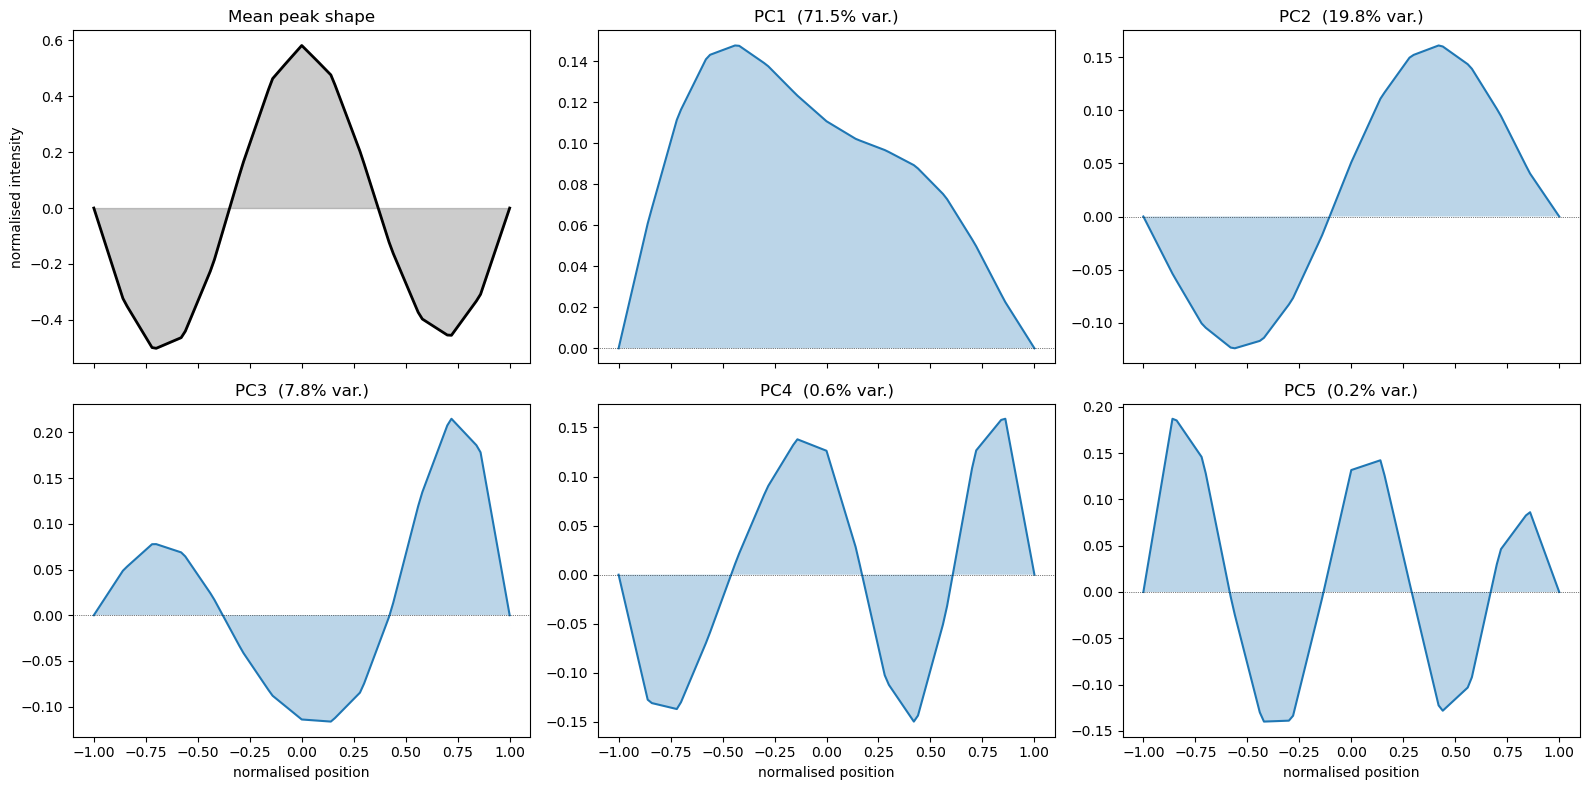

In [6]:
x_norm = np.linspace(-1, 1, n_window_pts)

n_panels = n_comp + 1  # mean + PCs
n_cols = 3
n_rows = (n_panels + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows), sharex=True)
axes = axes.flatten()

# Mean peak
ax = axes[0]
ax.plot(x_norm, mean_peak, 'k', lw=2)
ax.set_title('Mean peak shape')
ax.set_ylabel('normalised intensity')
ax.fill_between(x_norm, mean_peak, alpha=0.2, color='k')

# PCs
for i in range(n_comp):
    ax = axes[i + 1]
    pc = components[i]
    ax.plot(x_norm, pc, lw=1.5)
    ax.axhline(0, color='k', lw=0.5, ls=':')
    ax.fill_between(x_norm, pc, alpha=0.3)
    ax.set_title(f'PC{i+1}  ({evr[i]:.1%} var.)')

# Hide unused axes
for j in range(n_panels, len(axes)):
    axes[j].set_visible(False)

for ax in axes[n_cols * (n_rows - 1):]:
    if ax.get_visible():
        ax.set_xlabel('normalised position')

plt.tight_layout()
plt.show()